In [1]:
 !pip install datasets

# Data Load

In [2]:
from datasets import load_dataset
ds=load_dataset('roneneldan/TinyStories')

# Data Preprocessing

In [3]:
!pip install tiktoken

In [4]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm
import torch as th

In [5]:
encoding=tiktoken.get_encoding("gpt2")

def process(x):

    ids=encoding.encode_ordinary(x["text"])
    out={"ids":ids,"len":len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized=ds.map(process,remove_columns=["text"],desc="tokenizing the splits",num_proc=8)

    for split,dset in tokenized.items():
        arr_len=np.sum(dset['len'],dtype=np.uint64)
        filename=f'{split}.bin'
        dtype=np.uint16
        arr=np.memmap(filename,dtype=dtype,mode='w+',shape=(arr_len,))

        total_batches=1024
        idx=0
        for batch_idx in tqdm(range(total_batches),desc=f"writing {filename}"):
            batch=dset.shard(num_shards=total_batches,index=batch_idx,contiguous=True).with_format('numpy')
            arr_batch=np.concatenate(batch['ids'])
            arr[idx:idx+len(arr_batch)]=arr_batch
            idx+=len(arr_batch)
        arr.flush()


Input Output Pairs

In [6]:
th.randint(4,(5,))

tensor([0, 1, 1, 0, 3])

In [38]:
def get_batch(split):

    if split=="train":
        data=np.memmap("train.bin",dtype=np.uint16,mode='r')
    if split=="valid":
        data=np.memmap("validation.bin",dtype=np.uint16,mode='r')

    ix=th.randint(len(data)-block_size,(batch_size,))
    x=th.stack([th.from_numpy(data[i:i+block_size]).to(th.long) for i in ix])
    y=th.stack([th.from_numpy(data[i+1:i+1+block_size]).to(th.long) for i in ix])

    if device_type=="cuda":
        x,y=x.pin_memory().to(device,non_blocking=True),y.pin_memory().to(device,non_blocking=True)
    else:
        x,y=x.to(device),y.to(device)
    return x,y

SLM Architecture

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self,ndim,bias):
        super().__init__()

        self.weight=nn.Parameter(th.ones(ndim))
        self.bias=nn.Parameter(th.zeros(ndim)) if bias else None

    def forward(self,input):
        return F.layer_norm(input,self.weight.shape,self.weight,self.bias,1e-5)



class CausalSelgfAttention(nn.Module):

    def __init__(self,config):
        super().__init__()
        assert config.n_embed % config.n_head == 0
        self.c_attn=nn.Linear(config.n_embed,3*config.n_embed,bias=config.bias)
        self.c_proj=nn.Linear(config.n_embed,config.n_embed,bias=config.bias)

        self.attn_dropout=nn.Dropout(config.dropout)
        self.n_head=config.n_head
        self.n_embed=config.n_embed
        self.residual_dropout=nn.Dropout(config.dropout)

        self.flash=hasattr(F,"scaled_dot_product_attention")

    def forward(self,input):

        B,T,C=input.shape
        q,k,v=self.c_attn(input).split(self.n_embed,dim=2)

        k=k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q=q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v=v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)

        if self.flash:
            y=F.scaled_dot_product_attention(q,k,v,attn_mask=None,dropout_p=self.attn_dropout.p,is_causal=True)

        y=y.transpose(1,2).contiguous().view(B,T,C)
        y=self.residual_dropout(self.c_proj(y))

        return y


class MLP(nn.Module):

    def __init__(self,config):
        super().__init__()
        self.expansion=nn.Linear(config.n_embed,4*config.n_embed,bias=config.bias)
        self.c_proj=nn.Linear(4*config.n_embed,config.n_embed,bias=config.n_embed)

        self.dropout=nn.Dropout(config.dropout)
        self.GELU=nn.GELU()

    def forward(self,input):
        return self.dropout(self.c_proj(self.GELU(self.expansion(input))))

class Block(nn.Module):

    def __init__(self,config):
        super().__init__()
        self.ln_1=LayerNorm(config.n_embed,bias=config.bias)
        self.attn=CausalSelgfAttention(config)
        self.ln_2=LayerNorm(config.n_embed,bias=config.bias)
        self.mlp=MLP(config)

    def forward(self,input):
        input=self.attn(self.ln_1(input))+input
        input=self.mlp(self.ln_2(input))+input
        return input # Added return statement for block forward method

@dataclass
class GPTConfig:
    block_size:int
    vocab_size:int
    n_layer:int
    n_head:int
    n_embed:int
    dropout:float=0.0
    bias: bool=True

class GPT(nn.Module):

    def __init__(self,config):

        super().__init__()
        self.config=config
        self.transformer=nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size,config.n_embed),
            wpe=nn.Embedding(config.block_size,config.n_embed),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embed,config.bias),
        ))
        self.lm_head=nn.Linear(config.n_embed,config.vocab_size,bias=config.bias)
        self.transformer.wte.weight=self.lm_head.weight

        self.apply(self.init_weight)
        for pn,p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                nn.init.normal(p,mean=0.0,std=0.02/math.sqrt(2*config.n_layer))
    def init_weight(self,module):
         if isinstance(module,nn.Linear):
            nn.init.normal(module.weight,mean=0.0,std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

         elif isinstance(module,nn.Embedding):
                nn.init.normal(module.weight,mean=0.0)

    def forward(self,idx,targets=None):

        device=idx.device
        b,t=idx.shape

        assert t <= self.config.block_size
        pos=th.arange(0,t,dtype=th.long,device=device)
        pos_embed=self.transformer.wpe(pos)

        tok_embed=self.transformer.wte(idx)
        x=self.transformer.drop(pos_embed+tok_embed)

        for block in self.transformer.h:
            x=block(x)

        x=self.transformer.ln_f(x)

        if targets is not None:
            logits=self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits,loss

        if targets is  None:
            logits=self.lm_head(x[:,[-1],:])
            return logits,None

    @th.no_grad()
    def generate(self,idx,max_new_token,tempearture=1.0,top_k=None):

        for _ in range(max_new_token):
            idx_cond=idx if idx.shape[1] <= self.config.block_size else idx[:,-self.config.block_size:]
            logits,loss=self(idx_cond)
            logits=logits[:,-1,:]/tempearture

            if top_k is not None:
                v,_=th.topk(logits,min(top_k,logits.size(-1)))
                logits[logits<v[:,-1].unsqueeze(1)]=float('-inf')

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [40]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embed=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

/tmp/ipykernel_11415/2286768867.py:121: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(module.weight,mean=0.0)
/tmp/ipykernel_11415/2286768867.py:115: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(module.weight,mean=0.0,std=0.02)
/tmp/ipykernel_11415/2286768867.py:112: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(p,mean=0.0,std=0.02/math.sqrt(2*config.n_layer))


In [41]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'valid']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

In [42]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [43]:
model.parameters()

<generator object Module.parameters at 0x7eef8adcb300>

In [44]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_11415/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [48]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['valid']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['valid']]

        if losses['valid'] < best_val_loss:
            best_val_loss = losses['valid']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

Epoch 500: train loss 7.3756, val loss 7.3793
The current learning rate: 0.00010
Epoch 1000: train loss 6.7289, val loss 6.7322
The current learning rate: 0.00011
Epoch 1500: train loss 6.3106, val loss 6.3128
The current learning rate: 0.00011
Epoch 2000: train loss 6.0870, val loss 6.0834
The current learning rate: 0.00012
Epoch 2500: train loss 6.0075, val loss 6.0113
The current learning rate: 0.00012
Epoch 3000: train loss 5.9897, val loss 5.9894
The current learning rate: 0.00013
Epoch 3500: train loss 5.9814, val loss 5.9793
The current learning rate: 0.00014
Epoch 4000: train loss 5.9734, val loss 5.9744
The current learning rate: 0.00015
Epoch 4500: train loss 5.9703, val loss 5.9724
The current learning rate: 0.00016
Epoch 5000: train loss 5.9689, val loss 5.9706
The current learning rate: 0.00018
Epoch 5500: train loss 5.9580, val loss 5.9553
The current learning rate: 0.00019
Epoch 6000: train loss 5.9235, val loss 5.9255
The current learning rate: 0.00020
Epoch 6500: train

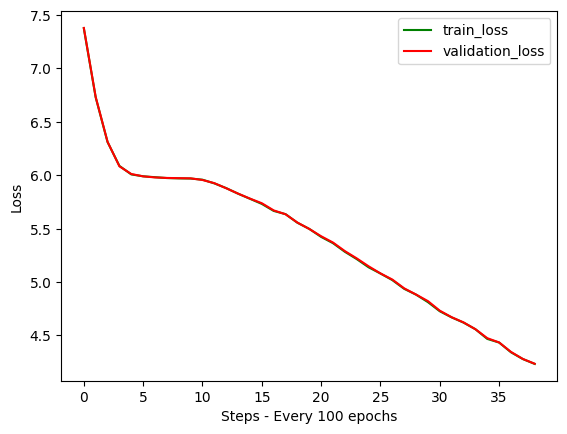

In [49]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [50]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


/tmp/ipykernel_11415/2286768867.py:121: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(module.weight,mean=0.0)
/tmp/ipykernel_11415/2286768867.py:115: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(module.weight,mean=0.0,std=0.02)
/tmp/ipykernel_11415/2286768867.py:112: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(p,mean=0.0,std=0.02/math.sqrt(2*config.n_layer))


<All keys matched successfully>

In [56]:
sentence = "Once upon a time there was a man."
context = (torch.tensor(encoding.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(encoding.decode(y.squeeze().tolist()))

Once upon a time there was a man. The brave don, she played wouldn. It bought put said, "Welcomet. She went to make something dear and mean the guard and. and draw meirled as each frog.

Mom's mom arrived to look said, "I we have help her owner. That are here. gazing was small doll". Stop wandered's good make do can not serious and lots!"

LThe little cubuch, "You sail! Youmy!

Let's ideaummy Lily!" but� not Lily. She wanted't argue the mosquito. I w are sorry was together their ball and were tooon. Sara's teacherens and mom."

Later was said, she says, Tim wanted to theYes and delay bright. P was happy't read nodded. Mom. It reached to make understand and play in him him.

Sam want and hears. She is the other hard away in to the park. They bent to put the basket was the small cars. He pull


In [57]:
!git config --global user.name "anb-io"
!git config --global user.email "anbugit007@gmail.com"

In [58]:
!git clone https://github.com/anb-io/SmallLanguageModel.git

Cloning into 'SmallLanguageModel'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [60]:
%cd /content/SmallLanguageModel

/content/SmallLanguageModel


In [62]:
!find /content -maxdepth 3 -type f | head -50

/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/default_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/config_sentinel
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/gce
/content/.config/configurations/config_default
/content/train.bin
/content/validation.bin
/content/SmallLanguageModel/.git/index
/content/SmallLanguageModel/.git/description
/content/SmallLanguageModel/.git/packed-refs
/content/SmallLanguageModel/.git/config
/content/SmallLanguageModel/.git/HEAD
/content/SmallLanguageModel/README.md
/content/best_model_params.pt
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv


In [64]:
!cp /content/*.ipynb .

cp: cannot stat '/content/*.ipynb': No such file or directory


In [65]:
!cp /content/*.bin .

In [63]:
!cp /content/*.pt .